# Configurable Greediness — Alternating Passes

Test whether the *sequence* of positive-reward greediness levels changes the basin reached by monotonic edge-flip search. Every schedule sees the same random seed colorings.

The primary experiment alternates 10 maximum-positive-reward moves (G100) with 10 minimum-still-positive-reward moves (G0), repeating until no positive edge flip remains. Constant G100 and constant G0 are matched controls. Ramp-up, ramp-down, and uniformly random per-step greediness schedules test whether sequencing itself matters. No negative moves, tabu memory, structural filtering, or neural policy is used.

In [1]:
# Experiment Configuration

RANDOM_SEED = 202_608_086
N_VERTICES = 43
NUMBER_OF_COLORINGS = 50
BLOCK_SIZE = 10
MAXIMUM_STEPS = 5_000
REPORT_EVERY_RUNS = 5

# Tuples are cycled by BLOCK_SIZE actions until positive-reward
# exhaustion. None means draw greediness uniformly from [0, 1] on
# every individual step. The first two schedules are controls.
SCHEDULES = {
    "G100": (1.0,),
    "G0": (0.0,),
    "G100-G0": (1.0, 0.0),
    "RAMP-UP": (0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0),
    "RAMP-DOWN": (1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.0),
    "RANDOM": None,
}

RUN_NAME = "configurable-greediness-alternating-passes-001"
DATABASE_FILENAME = "configurable_greediness_alternating_passes.sqlite3"

In [2]:
# Imports and Project Setup

from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ramsey import (
    RConfigurableGreedyPolicy,
    RConfigurableGreedyPolicyConfig,
    REnvironment,
    REnvironmentConfig,
    RGraph,
    RMonochromaticObjective,
    RNullMemory,
    RProblem,
    RRandomConstruction,
    RSQLiteArchive,
    calculate_flexibility,
)

project_root = Path.cwd().resolve()

if project_root.name == "notebooks":
    project_root = project_root.parent

if not (project_root / "ramsey").is_dir():
    raise RuntimeError(
        "Run this notebook from the RamseyNumber root "
        "or notebooks directory."
    )

DATABASE_PATH = (
    project_root
    / "data"
    / "experiments"
    / DATABASE_FILENAME
)

In [3]:
# Graph and Matched Random Seed Colorings

graph = RGraph(RProblem.r55(n_vertices=N_VERTICES))
construction_rng = np.random.default_rng(RANDOM_SEED)
construction = RRandomConstruction(construction_rng)

seed_colorings = [
    construction.construct(graph)
    for _ in range(NUMBER_OF_COLORINGS)
]

print("Edges:", f"{graph.number_of_edges:,}")
print("K5s:", f"{graph.subgraph_index(5).clique_count:,}")
print("Matched seed colorings:", NUMBER_OF_COLORINGS)
print("Block size:", BLOCK_SIZE)
print("Schedules:", SCHEDULES)
print("Maximum steps:", MAXIMUM_STEPS)
print("Database:", DATABASE_PATH.resolve())

Edges: 903
K5s: 962,598
Matched seed colorings: 50
Block size: 10
Schedules: {'G100': (1.0,), 'G0': (0.0,), 'G100-G0': (1.0, 0.0), 'RAMP-UP': (0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0), 'RAMP-DOWN': (1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.0), 'RANDOM': None}
Maximum steps: 5000
Database: C:\code\RamseyNumber\data\experiments\configurable_greediness_alternating_passes.sqlite3


In [4]:
# One Scheduled Run to Positive-Reward Exhaustion

def greediness_for_step(schedule, step, rng):
    if schedule is None:
        return float(rng.random())

    block = step // BLOCK_SIZE
    return float(schedule[block % len(schedule)])


def run_schedule(seed_coloring, schedule, rng):
    environment = REnvironment(
        graph=graph,
        objective=RMonochromaticObjective(),
        memory=RNullMemory(),
        config=REnvironmentConfig(
            max_steps=MAXIMUM_STEPS,
            use_aspiration=False,
        ),
    )
    environment.reset(seed_coloring)

    initial_score = environment.state.score
    trace = []
    exhausted = False
    wall_maximum_reward = None

    while not (environment.terminated or environment.truncated):
        analysis = environment.analyze_actions()
        rewards = analysis.action_analysis.immediate_rewards
        available_rewards = rewards[analysis.available_mask]
        positive_count = int(np.count_nonzero(available_rewards > 0))

        flexibility = calculate_flexibility(
            rewards,
            budgets=(0, 5),
        )

        if positive_count == 0:
            exhausted = True
            wall_maximum_reward = int(available_rewards.max())
            terminal_f0 = flexibility.fraction_at(0)
            terminal_f5 = flexibility.fraction_at(5)
            break

        step = environment.step_number
        block = step // BLOCK_SIZE
        greediness = greediness_for_step(schedule, step, rng)
        policy = RConfigurableGreedyPolicy(
            rng=rng,
            config=RConfigurableGreedyPolicyConfig(
                greediness=greediness,
            ),
        )
        edge = policy.select_action(environment)
        decision = policy.last_decision

        if decision is None:
            raise RuntimeError("Policy failed to record its decision.")

        edge_color = int(environment.state.colors[edge])
        profile = environment.state.action_profiles[edge]

        if edge_color == 1:
            violation_load = int(profile[10])
            blocking_load = int(profile[1])
        else:
            violation_load = int(profile[0])
            blocking_load = int(profile[9])

        score_before = environment.state.score
        result = environment.step(edge, full_analysis=False)

        if result.immediate_reward <= 0:
            raise RuntimeError(
                "Scheduled greedy run applied a nonpositive action."
            )

        if result.immediate_reward != violation_load - blocking_load:
            raise RuntimeError(
                "Violation/blocking loads disagree with exact reward."
            )

        trace.append({
            "step": step + 1,
            "block": block,
            "greediness": greediness,
            "score_before": score_before,
            "score_after": environment.state.score,
            "exact_reward": result.immediate_reward,
            "violation_load": violation_load,
            "blocking_load": blocking_load,
            "positive_actions": positive_count,
            "minimum_positive_reward": decision.minimum_positive_reward,
            "maximum_positive_reward": decision.maximum_positive_reward,
            "F0": flexibility.fraction_at(0),
            "F5": flexibility.fraction_at(5),
        })

    else:
        final_analysis = environment.analyze_actions()
        final_flexibility = calculate_flexibility(
            final_analysis.action_analysis.immediate_rewards,
            budgets=(0, 5),
        )
        terminal_f0 = final_flexibility.fraction_at(0)
        terminal_f5 = final_flexibility.fraction_at(5)

    return {
        "initial_score": initial_score,
        "final_score": environment.state.score,
        "final_coloring": environment.state.coloring_snapshot(),
        "steps": environment.step_number,
        "exhausted": exhausted,
        "solved": environment.terminated,
        "truncated": environment.truncated,
        "wall_maximum_reward": wall_maximum_reward,
        "terminal_F0": terminal_f0,
        "terminal_F5": terminal_f5,
        "trace": pd.DataFrame(trace),
    }

In [5]:
# Run Every Schedule on the Same Seed Batch

existing_archive = globals().get("archive")

if existing_archive is not None:
    existing_archive.close()

archive = RSQLiteArchive(DATABASE_PATH)
run_rows = []
trace_frames = []
all_results = {}
experiment_start = perf_counter()

for schedule_number, (schedule_name, schedule) in enumerate(SCHEDULES.items()):
    schedule_start = perf_counter()
    schedule_results = []

    print()
    print(schedule_name, schedule)
    print("-" * 56)

    for coloring_number, seed_coloring in enumerate(seed_colorings):
        action_rng = np.random.default_rng(
            RANDOM_SEED
            + 100_000 * (schedule_number + 1)
            + coloring_number
        )

        result = run_schedule(seed_coloring, schedule, action_rng)
        schedule_results.append(result)

        record = archive.save_coloring(
            result["final_coloring"],
            run_name=f"{RUN_NAME}-{schedule_name}",
            iteration=coloring_number,
        )

        run_rows.append({
            "schedule": schedule_name,
            "coloring": coloring_number,
            "initial_score": result["initial_score"],
            "final_score": result["final_score"],
            "steps": result["steps"],
            "terminal_F0": result["terminal_F0"],
            "terminal_F5": result["terminal_F5"],
            "exhausted": result["exhausted"],
            "solved": result["solved"],
            "truncated": result["truncated"],
            "wall_maximum_reward": result["wall_maximum_reward"],
            "archive_id": record.coloring_id,
        })

        trace = result["trace"].copy()
        trace.insert(0, "coloring", coloring_number)
        trace.insert(0, "schedule", schedule_name)
        trace_frames.append(trace)

        completed = coloring_number + 1

        if (
            completed % REPORT_EVERY_RUNS == 0
            or completed == NUMBER_OF_COLORINGS
        ):
            recent = schedule_results[-REPORT_EVERY_RUNS:]
            recent_finals = [item["final_score"] for item in recent]
            print(
                f"{completed:3d}/{NUMBER_OF_COLORINGS} | "
                f"recent mean final={np.mean(recent_finals):7.2f} | "
                f"recent min={min(recent_finals):4d}"
            )

    all_results[schedule_name] = schedule_results
    finals = np.asarray(
        [item["final_score"] for item in schedule_results],
        dtype=np.int32,
    )
    print(
        f"COMPLETE | mean={finals.mean():.2f} | "
        f"median={np.median(finals):.1f} | min={finals.min()} | "
        f"time={perf_counter() - schedule_start:.1f}s"
    )

runs = pd.DataFrame(run_rows)
traces = pd.concat(trace_frames, ignore_index=True)
experiment_elapsed = perf_counter() - experiment_start

print()
print("Total elapsed:", f"{experiment_elapsed:.1f}s")


G100 (1.0,)
--------------------------------------------------------
  5/50 | recent mean final= 296.00 | recent min= 281
 10/50 | recent mean final= 298.80 | recent min= 276
 15/50 | recent mean final= 309.80 | recent min= 288
 20/50 | recent mean final= 279.40 | recent min= 261
 25/50 | recent mean final= 296.60 | recent min= 267
 30/50 | recent mean final= 311.20 | recent min= 292
 35/50 | recent mean final= 295.20 | recent min= 281
 40/50 | recent mean final= 286.20 | recent min= 240
 45/50 | recent mean final= 290.00 | recent min= 261
 50/50 | recent mean final= 314.20 | recent min= 285
COMPLETE | mean=297.74 | median=299.5 | min=240 | time=26.4s

G0 (0.0,)
--------------------------------------------------------
  5/50 | recent mean final= 276.20 | recent min= 259
 10/50 | recent mean final= 278.60 | recent min= 249
 15/50 | recent mean final= 263.80 | recent min= 229
 20/50 | recent mean final= 264.40 | recent min= 260
 25/50 | recent mean final= 258.00 | recent min= 238
 30/50

In [6]:
# Final Report and Matched-Seed Comparisons

summary = (
    runs.groupby("schedule", sort=False)
    .agg(
        mean_initial=("initial_score", "mean"),
        mean_final=("final_score", "mean"),
        median_final=("final_score", "median"),
        minimum_final=("final_score", "min"),
        mean_steps=("steps", "mean"),
        mean_terminal_F0=("terminal_F0", "mean"),
        mean_terminal_F5=("terminal_F5", "mean"),
        exhausted=("exhausted", "sum"),
    )
    .reset_index()
    .sort_values(["mean_final", "median_final"])
    .reset_index(drop=True)
)

display(summary.round(4))

pivot = runs.pivot(
    index="coloring",
    columns="schedule",
    values="final_score",
)

print()
print("MATCHED-SEED ADVANTAGE OVER G100")
print("(positive means the method finished below G100)")

for method in SCHEDULES:
    if method == "G100":
        continue

    difference = pivot["G100"] - pivot[method]
    print(
        f"{method:10s} | "
        f"wins={int(np.count_nonzero(difference > 0)):2d}/"
        f"{len(difference):2d} | "
        f"mean advantage={difference.mean():+7.2f} | "
        f"median={difference.median():+6.1f} | "
        f"range=[{difference.min():+d}, {difference.max():+d}]"
    )

print()
print("BEST METHOD BY MEAN TERMINAL SCORE:", summary.iloc[0]["schedule"])

,schedule,mean_initial,mean_final,median_final,minimum_final,mean_steps,mean_terminal_F0,mean_terminal_F5,exhausted
0,G0,1873.96,266.26,264.5,226,1589.76,0.0112,0.2339,50
1,RAMP-DOWN,1873.96,283.50,282.0,248,256.14,0.0122,0.2492,50
2,RAMP-UP,1873.96,283.94,282.5,249,292.52,0.0117,0.2476,50
3,RANDOM,1873.96,290.40,290.0,252,275.16,0.0115,0.2510,50
4,G100-G0,1873.96,295.52,292.0,254,191.48,0.0130,0.2588,50
5,G100,1873.96,297.74,299.5,240,137.68,0.0124,0.2587,50



MATCHED-SEED ADVANTAGE OVER G100
(positive means the method finished below G100)
G0         | wins=45/50 | mean advantage= +31.48 | median= +29.0 | range=[-36, +94]
G100-G0    | wins=25/50 | mean advantage=  +2.22 | median=  +0.5 | range=[-56, +61]
RAMP-UP    | wins=36/50 | mean advantage= +13.80 | median= +15.5 | range=[-67, +84]
RAMP-DOWN  | wins=33/50 | mean advantage= +14.24 | median= +12.5 | range=[-46, +90]
RANDOM     | wins=32/50 | mean advantage=  +7.34 | median= +11.0 | range=[-50, +77]

BEST METHOD BY MEAN TERMINAL SCORE: G0


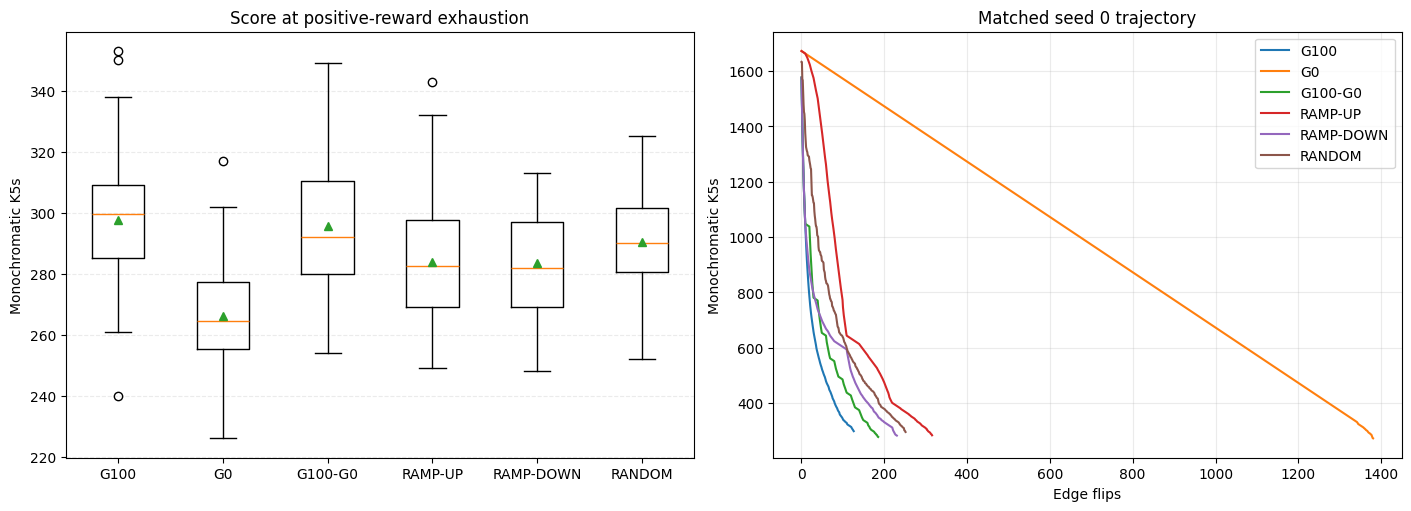


Trace columns available for basin analysis:
['schedule', 'coloring', 'step', 'block', 'greediness', 'score_before', 'score_after', 'exact_reward', 'violation_load', 'blocking_load', 'positive_actions', 'minimum_positive_reward', 'maximum_positive_reward', 'F0', 'F5']


In [7]:
# Final Scores and One Matched Trajectory

figure, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    constrained_layout=True,
)

score_data = [
    runs.loc[runs["schedule"] == name, "final_score"].to_numpy()
    for name in SCHEDULES
]
axes[0].boxplot(
    score_data,
    tick_labels=list(SCHEDULES),
    showmeans=True,
)
axes[0].set_title("Score at positive-reward exhaustion")
axes[0].set_ylabel("Monochromatic K5s")
axes[0].grid(axis="y", linestyle="--", alpha=0.25)

example = traces[traces["coloring"] == 0]

for schedule_name in SCHEDULES:
    trajectory = example[example["schedule"] == schedule_name]
    axes[1].plot(
        trajectory["step"],
        trajectory["score_after"],
        label=schedule_name,
        linewidth=1.5,
    )

axes[1].set_title("Matched seed 0 trajectory")
axes[1].set_xlabel("Edge flips")
axes[1].set_ylabel("Monochromatic K5s")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.show()

print()
print("Trace columns available for basin analysis:")
print(list(traces.columns))